In [176]:
%load_ext autoreload
%autoreload 2
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

import objax
import bayesnewton
import xarray as xr
import seaborn as sns
import pickle
import time
from tqdm.notebook import tqdm

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [126]:
z500 = xr.open_mfdataset('data/5.625deg/geopotential_500/*.nc', combine='by_coords')
z500_train = z500.sel(time=slice('2017.12.1', '2017.12.14'), lat=slice(0, None, 2), lon=slice(0, None, 4))['z']
z500_test= z500.sel(time=slice('2017.12.15', '2017.12.17'), lat=slice(0, None, 2), lon=slice(0, None, 4))['z']

In [127]:
data_mean = z500_train.mean().load()
data_std = z500_train.std().load()

# Normalize datasets
data_train = (z500_train - data_mean) / data_std

In [128]:
t_train = (data_train.time - data_train.time[0]).values
t_train = t_train / np.timedelta64(1, 'h')

In [129]:
from model import ExactMarkovGP

In [130]:
lat = jnp.array(data_train.lat)
lon = jnp.array(data_train.lon)
t_train = jnp.array(t_train)
z_train = jnp.array(data_train.values)

In [131]:
z_train.shape

(336, 8, 16)

In [132]:
LAT, LON = jnp.meshgrid(lat, lon, indexing='ij')
R = jnp.stack([LAT.ravel(), LON.ravel()], axis=-1)
R = jnp.repeat(R[None, ...], z_train.shape[0], axis=0)
Y = z_train.reshape(-1, 8*16)

In [133]:
t_train.shape, R.shape, Y.shape

((336,), (336, 128, 2), (336, 128))

In [ ]:
lengthscale_spatial = 0.1
lengthscale_temporal = 13.6
variance_spatial = 0.2
variance_temporal = 0.2

variance_noise = 0.00001

lik = bayesnewton.likelihoods.Gaussian(variance=variance_noise)
kern_time = bayesnewton.kernels.Matern52(variance=variance_temporal, lengthscale=lengthscale_temporal)
kern_space = bayesnewton.kernels.Matern52(variance=variance_spatial, lengthscale=lengthscale_spatial)
kernel = bayesnewton.kernels.SpatioTemporalKernel(temporal_kernel=kern_time, spatial_kernel=kern_space, z=R[0], sparse=False, opt_z=False)
gp = ExactMarkovGP(kernel, lik, X=t_train, R=R, Y=Y)

In [227]:
lr_adam = 0.5
epochs = 10

opt_hypers = objax.optimizer.Adam(gp.vars())
energy = objax.GradValues(gp.filter_energy, gp.vars())

def train_op():
    grads, loss_ = energy()  # compute energy and its gradients w.r.t. hypers
    opt_hypers(lr_adam, grads)
    return loss_[0]

train_op = objax.Jit(train_op, gp.vars())

t0 = time.time()
for i in range(1, epochs+1):
    loss = train_op()
    print('epoch %2d: loss: %1.4f' % (i, loss))
t1 = time.time()
print('optimisation time: %2.2f secs' % (t1-t0))

epoch  1: loss: -122150.6799
epoch  2: loss: -123503.4536
epoch  3: loss: -124497.3579
epoch  4: loss: -125255.5058
epoch  5: loss: -124354.7933
epoch  6: loss: -125255.5058
epoch  7: loss: -124354.7933
epoch  8: loss: -125255.5058
epoch  9: loss: -124354.7933
epoch 10: loss: -125255.5058
optimisation time: 121.02 secs


In [221]:
print(lengthscale_spatial, lengthscale_temporal, variance_spatial, variance_temporal)
gp.kernel.spatial_kernel.lengthscale, gp.kernel.temporal_kernel.lengthscale, gp.kernel.spatial_kernel.variance, gp.kernel.temporal_kernel.variance

0.1 13.6 0.2 0.2


(Array(0.1, dtype=float64, weak_type=True),
 Array(14.59999922, dtype=float64, weak_type=True),
 Array(0.2, dtype=float64, weak_type=True),
 Array(0.2, dtype=float64, weak_type=True))

In [222]:
data_test_mean = z500_test.mean().load()
data_test_std = z500_test.std().load()

# Normalize data_testsets
data_test = (z500_test - data_test_mean) / data_test_std

t_test = (data_test.time - data_test.time[0]).values
t_test = t_test / np.timedelta64(1, 'h') + t_train[-1]

In [209]:
train_mean, train_std = gp.predict(t_train)

In [228]:
test_mean, test_std = gp.predict(t_test)

In [224]:
train_mean = train_mean.reshape(-1, 8, 16)
train_std = train_std.reshape(-1, 8, 16)

In [229]:
test_mean = test_mean.reshape(-1, 8, 16)
test_std = test_std.reshape(-1, 8, 16)

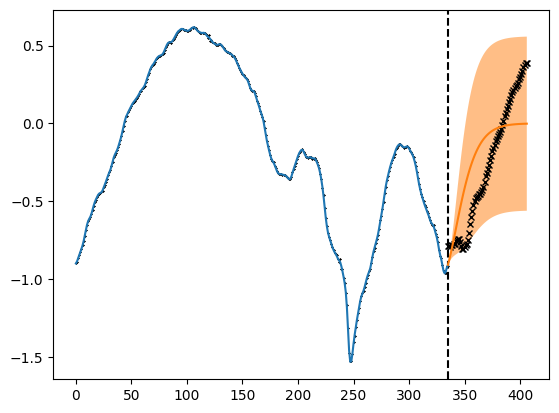

In [230]:
plt.plot(t_train, data_train[:, 4, 0], color='black', marker='x', linestyle='none', ms=1)
plt.plot(t_test, data_test[:, 4, 0], color='black', marker='x', linestyle='none', ms=5)
plt.axvline(t_train[-1], color='black', linestyle='--')
plt.plot(t_train, train_mean[:, 4, 0], alpha=1)
plt.fill_between(t_train, train_mean[:, 4, 0] - 2*train_std[:, 4, 0], train_mean[:, 4, 0] + 2*train_std[:, 4, 0], alpha=0.5)
plt.plot(t_test, test_mean[:, 4, 0], alpha=1)
plt.fill_between(t_test, test_mean[:, 4, 0] - 2*test_std[:, 4, 0], test_mean[:, 4, 0] + 2*test_std[:, 4, 0], alpha=0.5)

In [ ]:
plt.fill_between(t_test.squeeze(), test_mean[:, 1] - 2 * test_std[:, 1], test_mean[:, 1] + 2 * test_std[:, 1], alpha=0.25)
plt.fill_between(t_test.squeeze(), test_mean[:, 2] - 2 * test_std[:, 2], test_mean[:, 2] + 2 * test_std[:, 2], alpha=0.25)
plt.title(f"Marginal likelhood: {-gp.filter_energy()}")